# Projekt: Credit Card Fraud Detection (Detekcja Anomalii)
    
Dataset: `https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data`

# 1. Przygotowanie datasetu - import bibliotek + załadowanie dataset'u

In [ ]:
# Podstawowe biblioteki
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Scikit-learn - preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Scikit-learn - modele
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix

import kagglehub


path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Ścieżka do pobranych plików:", path)

# Kagglehub pobiera pliki do dziwnych folderów w cache.
# Musimy znaleźć plik CSV w tym folderze:
csv_file = os.path.join(path, "creditcard.csv")

# Wczytanie
df = pd.read_csv(csv_file)

print(df.info())

print("Pomyślnie załadowano dataset!")

# 2. Pierwsze wizualizacjie (plotting)

### Cel: zwizualizować, że w wybranym datasecie transakcje oszustwa to 0.2%

In [ ]:

colors = ["#6D52E7", "#FF0000"]

plt.pie(
    df['Class'].value_counts(),
    shadow = False,
    colors = colors,
    startangle=90,
    autopct='%1.1f%%',
    labels = ['Normal', 'Fraud']
)
plt.axis('equal')
plt.tight_layout()
plt.show()


## Wniosek: dataset jest ekstremalnie niezbalansowany

### 2.1 Heatmap korelacji (plotting)

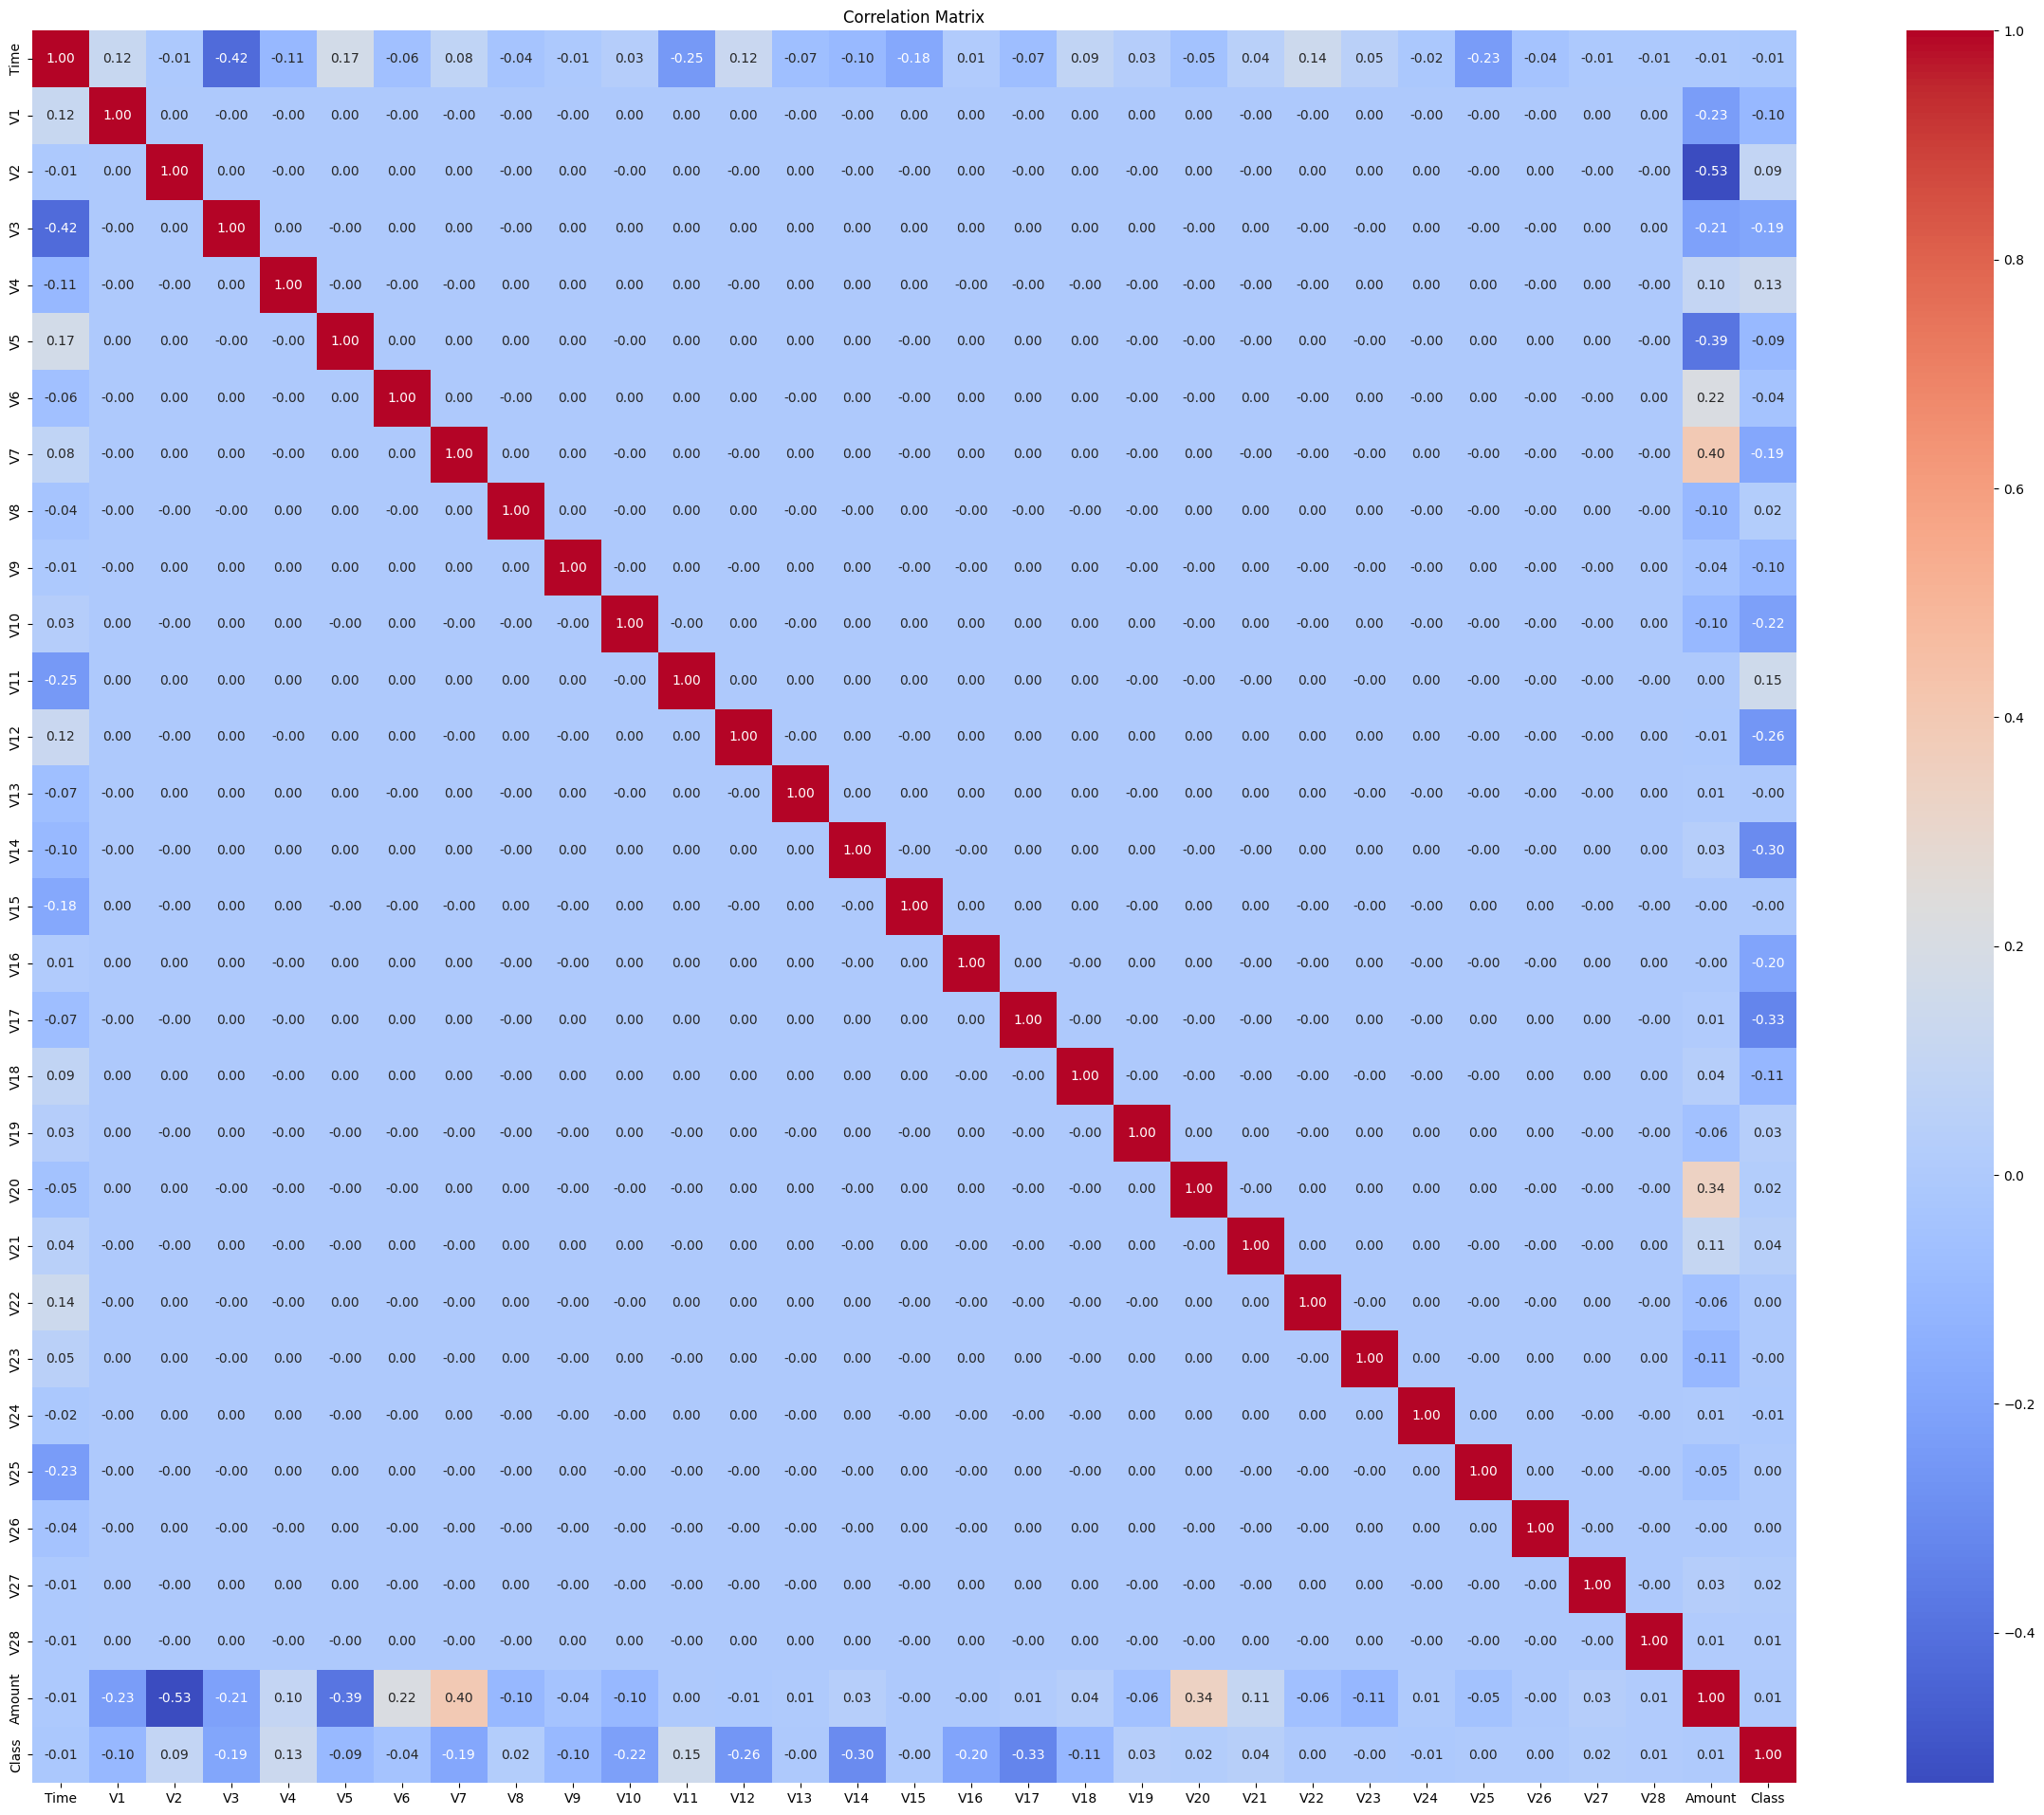

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


In [14]:
plt.figure(figsize=(30, 24))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

print(df.corr()['Class'].sort_values(ascending=False))


## Z Class najbardziej korelują cechy:
    1. V17 -0.33
    2. V14 -0.30
    3. V12 -0.26